In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


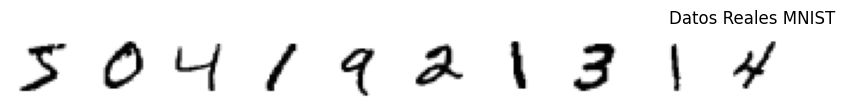

In [ ]:
# Cargamos y preprocesamos el dataset MNIST (dígitos)
mnist = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist

X_train_full = X_train_full.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Mostramos de los datos reales para verificar
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap="binary")
    plt.axis("off")
plt.title("Datos Reales MNIST")
plt.show()

In [ ]:
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")

In [ ]:
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

In [ ]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
    generator, discriminator = gan.layers
    for epoch in range(n_epochs):
        print(f"Epoch {epoch + 1}/{n_epochs}")  # extra code
        for X_batch in dataset:
            # phase 1 - training the discriminator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            generated_images = generator(noise)
            X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
            y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
            discriminator.trainable = True
            discriminator.train_on_batch(X_fake_and_real, y1)
            discriminator.trainable = False
            # phase 2 - training the generator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            y2 = tf.constant([[1.]] * batch_size)
            gan.train_on_batch(noise, y2)
        # extra code — plot images during training
        plot_multiple_images(generated_images.numpy(), 8)
        plt.show()



In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

def build_and_train_gan(codings_size, n_epochs=50):
    print(f"\nIniciando entrenamiento con Codings Size: {codings_size}")

    # Construimos el Generador
    generator = tf.keras.Sequential([
        tf.keras.layers.Dense(100, activation="relu", input_shape=[codings_size]),
        tf.keras.layers.Dense(150, activation="relu"),
        tf.keras.layers.Dense(28 * 28, activation="sigmoid"),
        tf.keras.layers.Reshape([28, 28])
    ])

    # Construimos el Discriminador
    discriminator = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),
        tf.keras.layers.Dense(150, activation="relu"),
        tf.keras.layers.Dense(100, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    gan = tf.keras.Sequential([generator, discriminator])

    # Compilamos
    discriminator.compile(loss="binary_crossentropy", optimizer="rmsprop")
    discriminator.trainable = False
    gan.compile(loss="binary_crossentropy", optimizer="rmsprop")

    # Dataset
    batch_size = 32
    dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
    dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

    # Entrenamos
    train_gan(gan, dataset, batch_size, codings_size, n_epochs)

    return generator


Iniciando entrenamiento con Codings Size: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


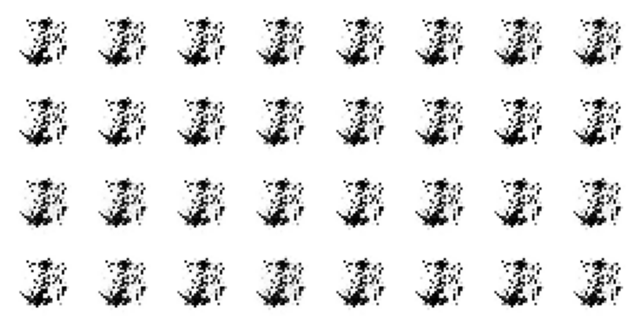

Epoch 2/10


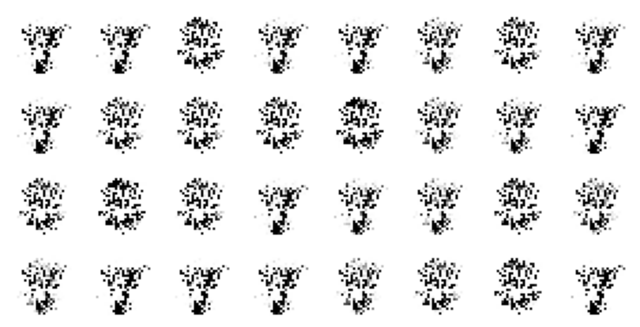

Epoch 3/10


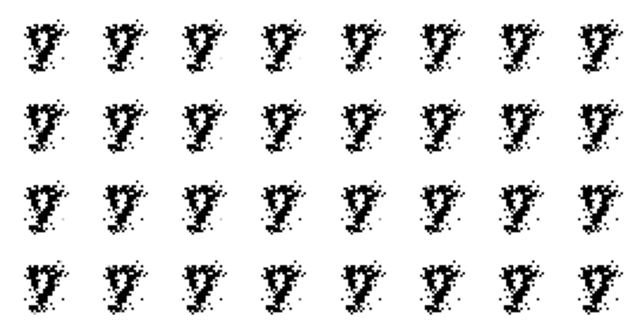

Epoch 4/10


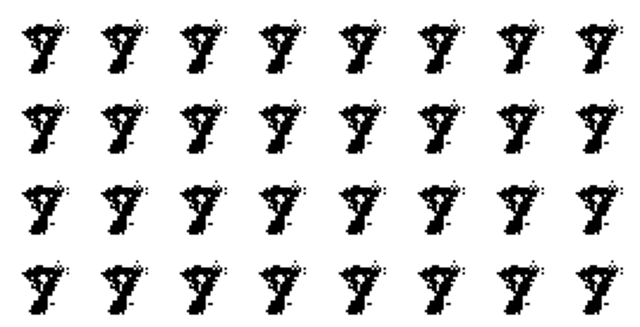

Epoch 5/10


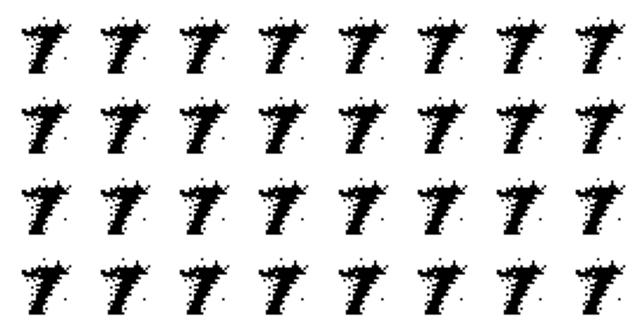

Epoch 6/10


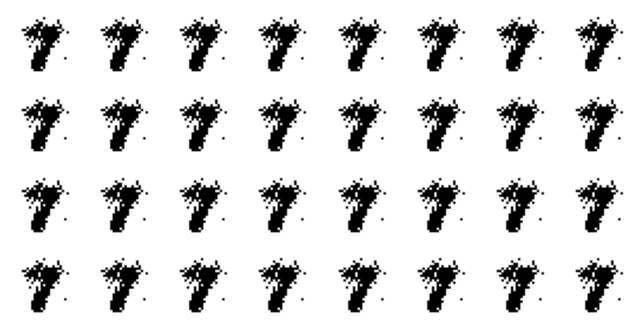

Epoch 7/10


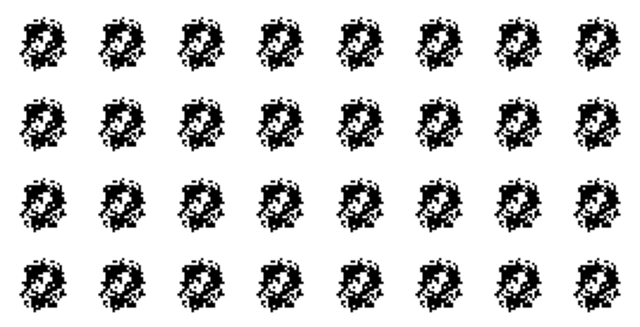

Epoch 8/10


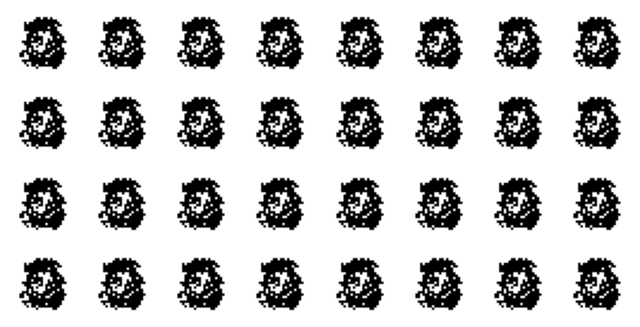

Epoch 9/10


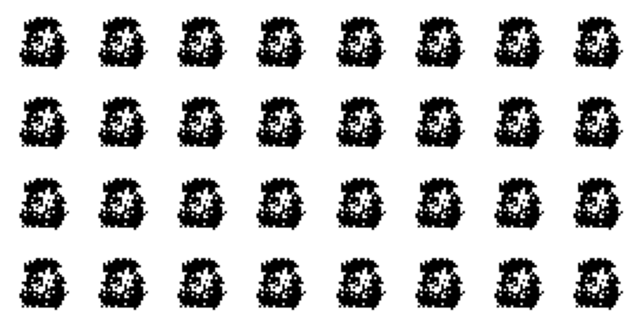

Epoch 10/10


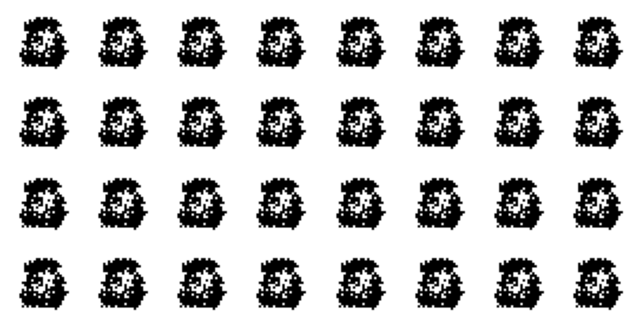


Iniciando entrenamiento con Codings Size: 50
Epoch 1/10


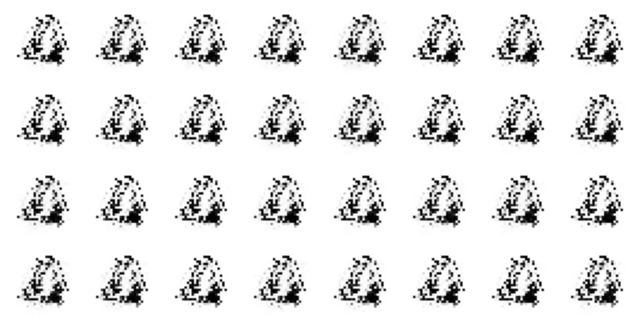

Epoch 2/10


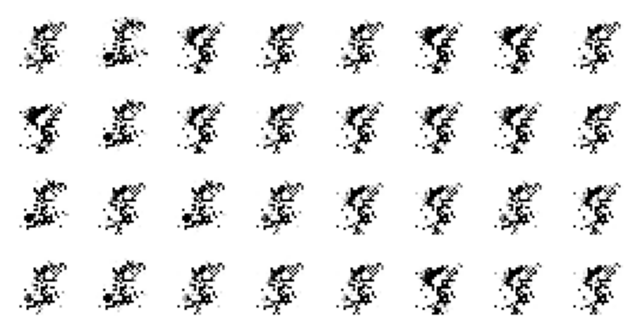

Epoch 3/10


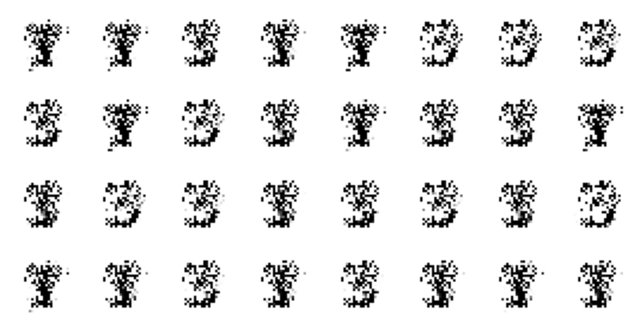

Epoch 4/10


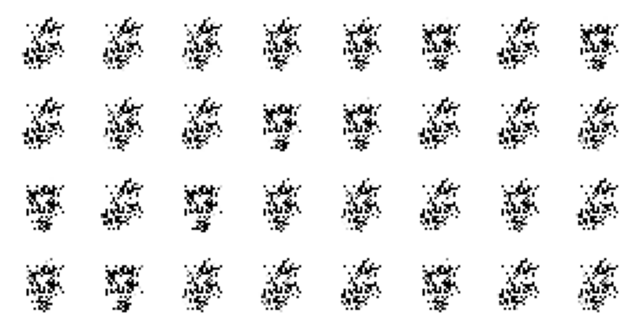

Epoch 5/10


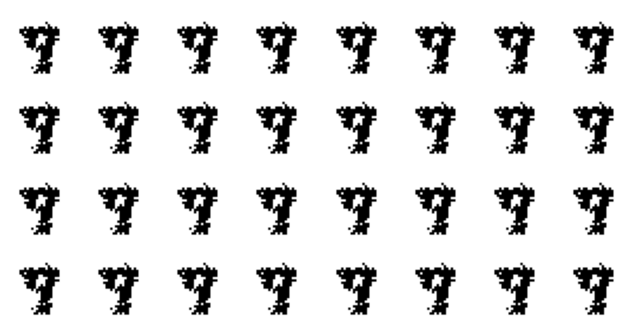

Epoch 6/10


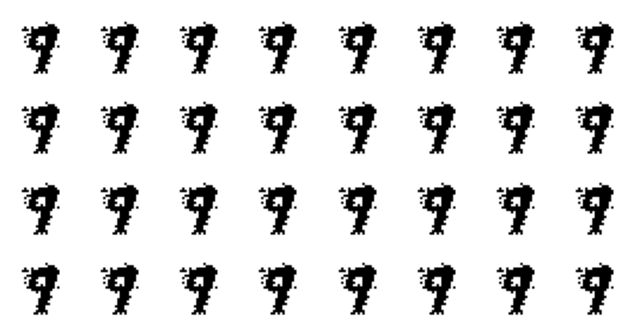

Epoch 7/10


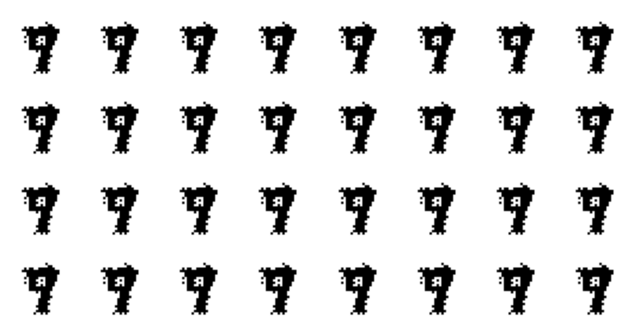

Epoch 8/10


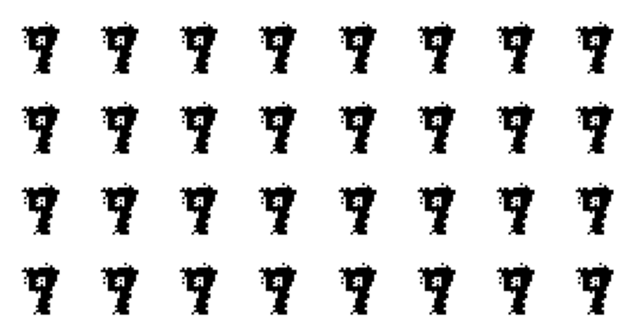

Epoch 9/10


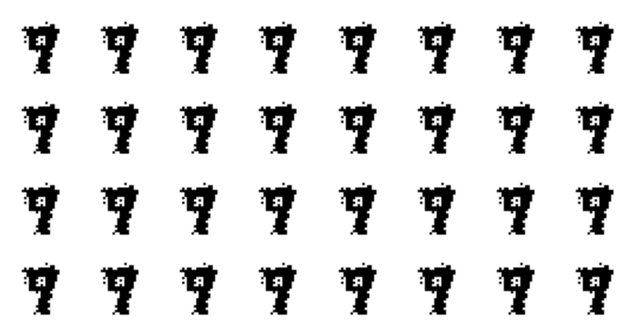

Epoch 10/10


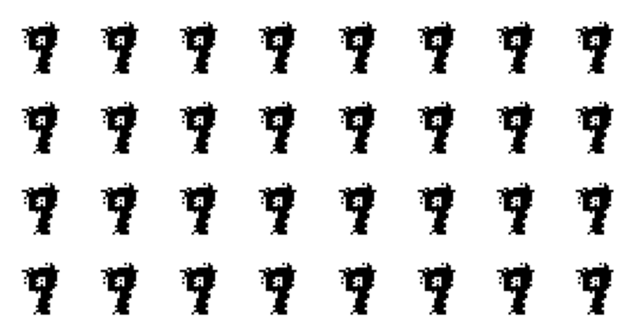


Iniciando entrenamiento con Codings Size: 100
Epoch 1/10


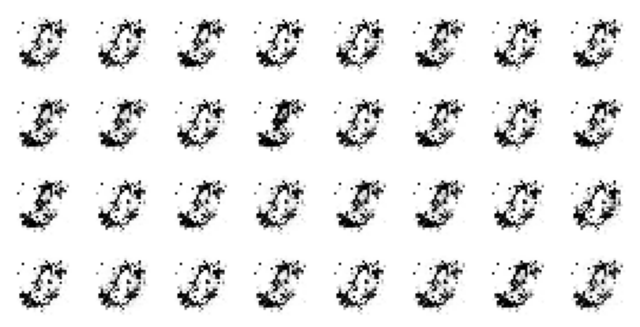

Epoch 2/10


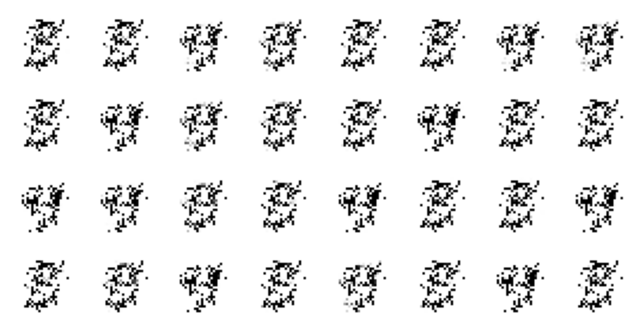

Epoch 3/10


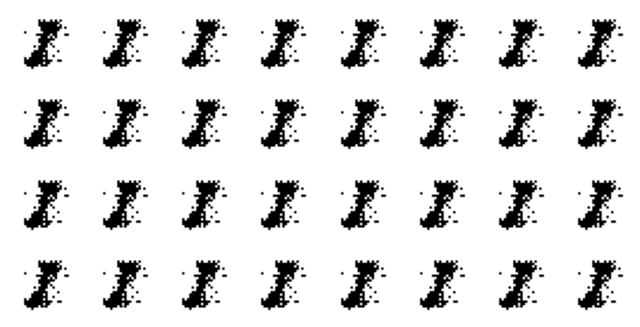

Epoch 4/10


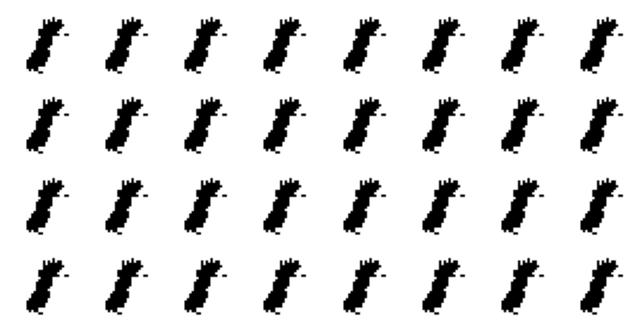

Epoch 5/10


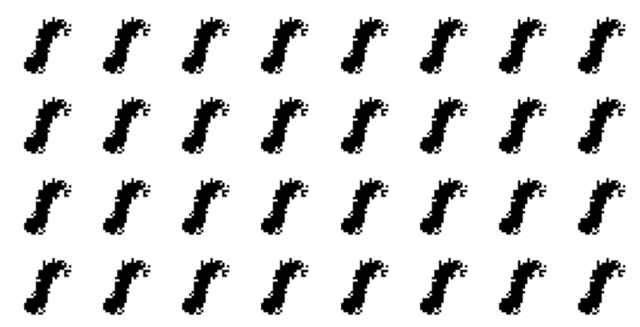

Epoch 6/10


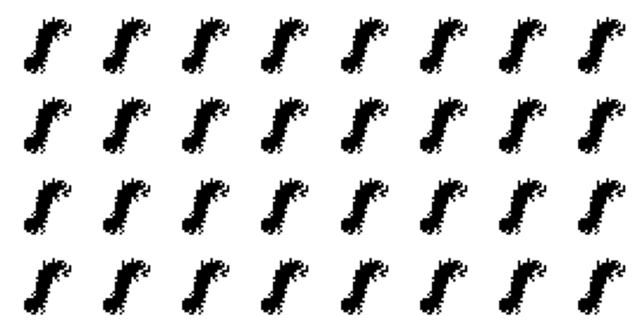

Epoch 7/10


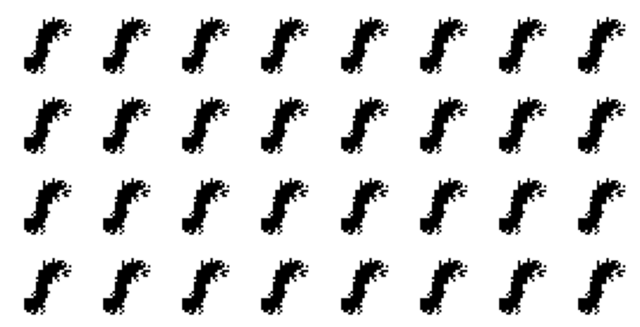

Epoch 8/10


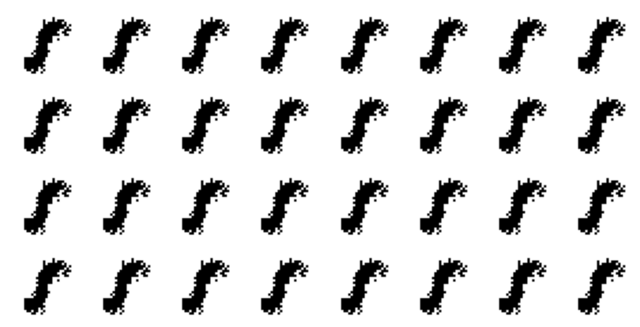

Epoch 9/10


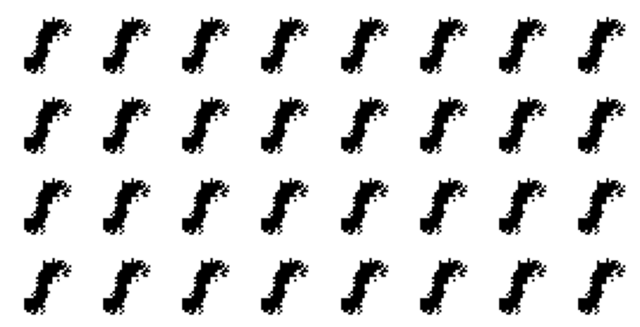

Epoch 10/10


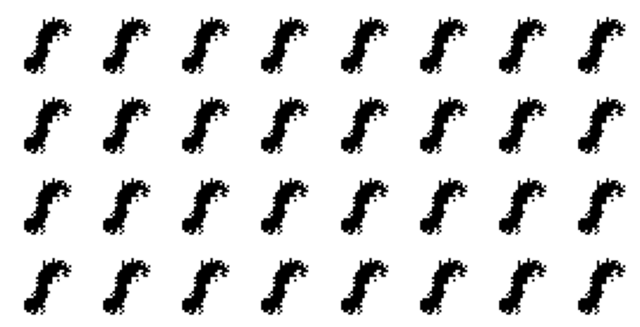

In [ ]:
# BUCLE PRINCIPAL
sizes_to_test = [10, 50, 100]
trained_generators = {}

for size in sizes_to_test:
    # Entrenamos y guardamos el generador resultante
    trained_generators[size] = build_and_train_gan(codings_size=size, n_epochs=10)


RESULTADOS FINALES


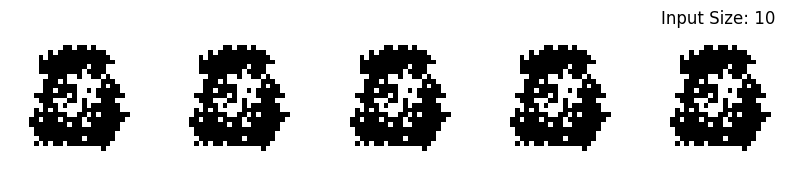

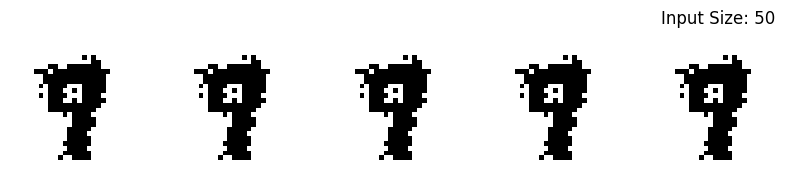

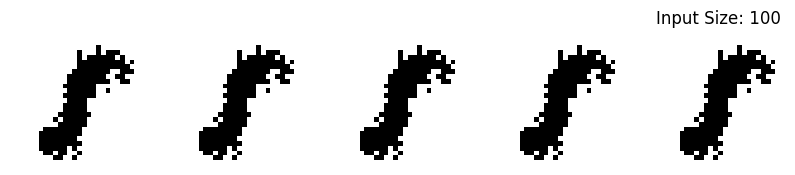

In [ ]:
def plot_generated_images(generator, codings_size, num_images=5):
    # Generar ruido aleatorio
    noise = tf.random.normal(shape=[num_images, codings_size])
    # Generar imágenes
    generated_images = generator(noise)

    plt.figure(figsize=(10, 2))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(generated_images[i], cmap="binary")
        plt.axis("off")
    plt.title(f"Input Size: {codings_size}")
    plt.show()

print("\nRESULTADOS FINALES")
for size in sizes_to_test:
    plot_generated_images(trained_generators[size], size)

In [ ]:
for size in sizes_to_test:
    print(f"\nGeneradas con vector de entrada tamaño {size}:")

    # Generamos 32 imágenes (un bloque estándar)
    noise = tf.random.normal(shape=[32, size])
    generated_images = trained_generators[size](noise)

    # Mostramos el bloque (8 columnas x 4 filas)
    plot_multiple_images(generated_images, n_cols=8)
    plt.show()